covid

import libraries and csv file

In [2]:
pip install -U scikit-learn

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB 640.0 kB/s eta 0:00:17
   ---------------------------------------- 0.1/10.6 MB 975.2 kB/s eta 0:00:11
   - -------------------------------------- 0.3/10.6 MB 2.3 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/10.6 MB 6.2 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/10.6 MB 12.0 MB/s eta 0:00:01
   ---------- ----------------------------- 2.8/10.6 MB 12.1 MB/s eta 0:00:01
   --------------- ------------------------ 4.0/10.6 MB 15.1 MB/s eta 0:00:01
   ----------------------- ---------------- 6.2/10.6 MB 18.1 MB/s eta 0:00:01
   ------------------------------ --------- 8.1/10.6 MB 20.6 MB/s eta 0:00:01
   ------------------------------------- -- 10.0/10.6 MB 22.8 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 28.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: 

In [3]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#import csv file
covid = pd.read_csv("CovidData/Covid Data.csv")

In [5]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

prepare data

In [6]:
# delete duplicate rows
covid.drop_duplicates(inplace=True)

In [7]:
# delete not used columns
covid.drop(columns=['MEDICAL_UNIT','USMER'], inplace =True)

In [8]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 236526 entries, 0 to 1048574
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   SEX                   236526 non-null  int64 
 1   PATIENT_TYPE          236526 non-null  int64 
 2   DATE_DIED             236526 non-null  object
 3   INTUBED               236526 non-null  int64 
 4   PNEUMONIA             236526 non-null  int64 
 5   AGE                   236526 non-null  int64 
 6   PREGNANT              236526 non-null  int64 
 7   DIABETES              236526 non-null  int64 
 8   COPD                  236526 non-null  int64 
 9   ASTHMA                236526 non-null  int64 
 10  INMSUPR               236526 non-null  int64 
 11  HIPERTENSION          236526 non-null  int64 
 12  OTHER_DISEASE         236526 non-null  int64 
 13  CARDIOVASCULAR        236526 non-null  int64 
 14  OBESITY               236526 non-null  int64 
 15  RENAL_CHRONIC        

In [9]:
# rename columns
covid.rename(columns=
             {'PATIENT_TYPE':'HOSPITALIZED',
              'DATE_DIED':'DEAD',
              'INMSUPR': 'IMMUNOSUPPRESSED',
              'CLASIFFICATION_FINAL': 'COVID_TEST_RESULT',
              'TOBACCO': "SMOKER",
              'CARDIOVASCULAR': 'CARDIOVASCULAR_DISEASE',
              'RENAL_CHRONIC': 'CHRONIC_KIDNEY_DISEASE',
              'ICU': 'ADMITTED_TO_ICU'}, inplace=True)

In [10]:
# update columns order
covid = covid.loc[:,
                  ['COVID_TEST_RESULT', 
                   'HOSPITALIZED',
                   'INTUBED',
                   'ADMITTED_TO_ICU',
                   'DEAD',
                   'AGE',
                   'SEX',
                   'PREGNANT',
                   'SMOKER',
                   'PNEUMONIA',
                   'COPD',
                   'ASTHMA',
                   'IMMUNOSUPPRESSED',
                   'CARDIOVASCULAR_DISEASE',
                   'HIPERTENSION',
                   'CHRONIC_KIDNEY_DISEASE',
                   'DIABETES',
                   'OBESITY',
                   'OTHER_DISEASE']]

In [11]:
# column "DEAD" dead: 1, alive: 0
covid['DEAD'] = covid['DEAD'].replace({'9999-99-99': 0})
covid['DEAD'] = covid['DEAD'].apply(lambda x: 1 if x != 0 else 0)

In [12]:
# column "SEX" female: 1, male: 0
covid['SEX'] = covid['SEX'].replace({2:0})

In [13]:
# change 2 for 0 ('False'), 97, 98 and 99 for 0
covid[['INTUBED','ADMITTED_TO_ICU','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED',
       'CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']] = covid[[
           'INTUBED','ADMITTED_TO_ICU','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED',
           'CARDIOVASCULAR_DISEASE','HIPERTENSION', 'CHRONIC_KIDNEY_DISEASE','DIABETES','OBESITY','OTHER_DISEASE']].replace({2: 0, 97: 0, 98: 0, 99: 0})

In [14]:
#change column "HOSPITALIZED" to 0,1 format
covid['HOSPITALIZED'] = covid['HOSPITALIZED'].replace({1: 0, 2: 1})

In [15]:
#update column "COVID_TEST_RESULT" to 0,1 format
covid['COVID_TEST_RESULT'] = covid['COVID_TEST_RESULT'].apply(lambda x: 1 if x in [1,2,3] else 0)

In [16]:
covid["COVID_TEST_RESULT"].value_counts()

COVID_TEST_RESULT
0    123238
1    113288
Name: count, dtype: int64

In [17]:
covid['COVID_NEGATIV'] = covid['COVID_TEST_RESULT'] == 0

In [18]:
covid['COVID_NEGATIV'].replace({False: 0, True: 1}, inplace=True)

C:\Users\bartb\AppData\Local\Temp\ipykernel_11336\617110477.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  covid['COVID_NEGATIV'].replace({False: 0, True: 1}, inplace=True)
C:\Users\bartb\AppData\Local\Temp\ipykernel_11336\617110477.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  covid['COV

In [19]:
covid['COVID_NEGATIV']

0          0
1          1
2          0
3          1
4          0
          ..
1048568    1
1048569    1
1048571    1
1048572    1
1048574    1
Name: COVID_NEGATIV, Length: 236526, dtype: int64

In [20]:
covid[["COVID_TEST_RESULT", "COVID_NEGATIV"]]

,COVID_TEST_RESULT,COVID_NEGATIV
0,1,0
1,0,1
2,1,0
3,0,1
4,1,0
...,...,...
1048568,0,1
1048569,0,1
1048571,0,1
1048572,0,1


In [21]:
#function creating a values for age group
def grouping_age(row) -> str:
    if row['AGE'] < 18:
        val = '-18'
    elif row['AGE'] < 30:
        val = '18-30'
    elif row['AGE'] < 45:
        val = '30-45'
    elif row['AGE'] < 60:
        val = '45-60'
    else:
        val = '60+'
    return val

In [22]:
#create column "AGE_GROUP"
covid["AGE_GROUP"] = covid.apply(grouping_age, axis=1)

In [23]:
#move column "AGE_GROUP" next to "AGE" column
column_to_move = covid.pop('AGE_GROUP')
covid.insert(6, "AGE_GROUP", column_to_move)

In [24]:
#create a table grouped by age and aggregated as sum
covid_age = covid.groupby("AGE_GROUP").sum()


In [25]:
#create a table grouped by age and aggregated as sum
covid_age_test = covid.groupby(["AGE_GROUP", "COVID_TEST_RESULT"]).size()

In [26]:
covid_age_test

AGE_GROUP  COVID_TEST_RESULT
-18        0                     8058
           1                     2198
18-30      0                    12582
           1                     6507
30-45      0                    26731
           1                    19994
45-60      0                    33850
           1                    35475
60+        0                    42017
           1                    49114
dtype: int64

In [27]:
covid_age

,COVID_TEST_RESULT,HOSPITALIZED,INTUBED,ADMITTED_TO_ICU,DEAD,AGE,SEX,PREGNANT,SMOKER,PNEUMONIA,COPD,ASTHMA,IMMUNOSUPPRESSED,CARDIOVASCULAR_DISEASE,HIPERTENSION,CHRONIC_KIDNEY_DISEASE,DIABETES,OBESITY,OTHER_DISEASE,COVID_NEGATIV
AGE_GROUP,,,,,,,,,,,,,,,,,,,,
-18,2198,5190,899,930,802,81093,4978,143,239,2535,78,1172,1170,636,299,298,300,916,1695,8058
18-30,6507,6516,951,775,1377,471186,10001,1452,3625,4421,301,2387,1188,831,2559,1297,1792,4837,1880,12582
30-45,19994,19864,3883,2385,7644,1752941,21825,1357,8419,15089,1113,4750,2633,2348,11236,2915,9603,15555,4121,26731
45-60,35475,39947,10370,4772,23014,3618935,30350,52,9509,30365,3026,4637,3403,4489,26773,5062,24899,22238,5335,33850
60+,49114,65127,16192,6521,43128,6521908,39869,16,10833,47320,9551,3090,3896,9607,47138,7532,37162,19782,6549,42017


In [28]:
test = covid[(covid["COVID_TEST_RESULT"]) == 1]

In [29]:
test_gr = test.groupby(["AGE_GROUP", "DEAD"]).size()

In [30]:
test_gr

AGE_GROUP  DEAD
-18        0        2003
           1         195
18-30      0        5796
           1         711
30-45      0       14783
           1        5211
45-60      0       18819
           1       16656
60+        0       18539
           1       30575
dtype: int64

In [31]:
18819+18539


37358

charts

C:\Users\bartb\AppData\Local\Temp\ipykernel_11336\2512485428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="AGE_GROUP", y="COVID_TEST_RESULT", estimator="sum", data=covid_age, palette="YlGnBu")


[Text(0.5, 0, 'grupa wiekowa'), Text(0, 0.5, 'ilość z pozytywnym testem')]

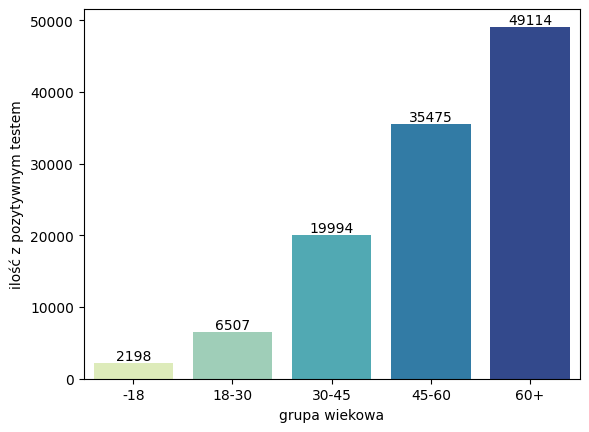

In [32]:
#sum of positive covid test in each age group
ax = sns.barplot(x="AGE_GROUP", y="COVID_TEST_RESULT", estimator="sum", data=covid_age, palette="YlGnBu")
for container in ax.containers:
    ax.bar_label(container)
ax.set(xlabel="grupa wiekowa", ylabel="ilość z pozytywnym testem")

In [33]:
# calculate the distribution of `Clicked` per `Rank`
distribution = pd.crosstab(covid["AGE_GROUP"], covid["COVID_TEST_RESULT"], normalize='index')


<Axes: xlabel='COVID_TEST_RESULT', ylabel='AGE_GROUP'>

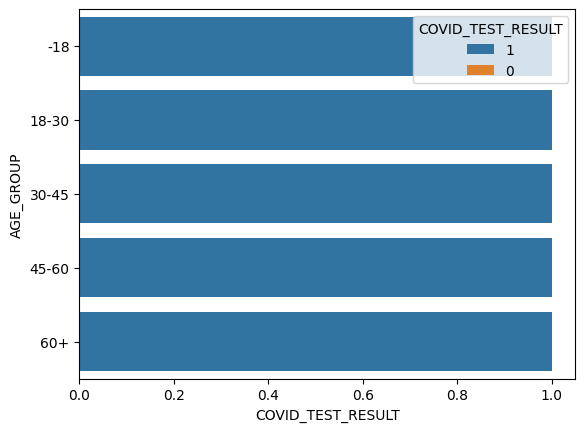

In [34]:

# plot the cumsum, with reverse hue order
sns.barplot(data=distribution.cumsum(axis=1).stack().reset_index(name='Dist'),
            x='COVID_TEST_RESULT', y='AGE_GROUP', hue='COVID_TEST_RESULT',
            hue_order = distribution.columns[::-1],   # reverse hue order so that the taller bars got plotted first
            dodge=False)

C:\Users\bartb\AppData\Local\Temp\ipykernel_11336\1806804264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="AGE_GROUP", y="DEAD", estimator="sum", data=covid_age, palette="YlGnBu")


[Text(0.5, 0, 'grupa wiekowa'), Text(0, 0.5, 'ilość zgonów')]

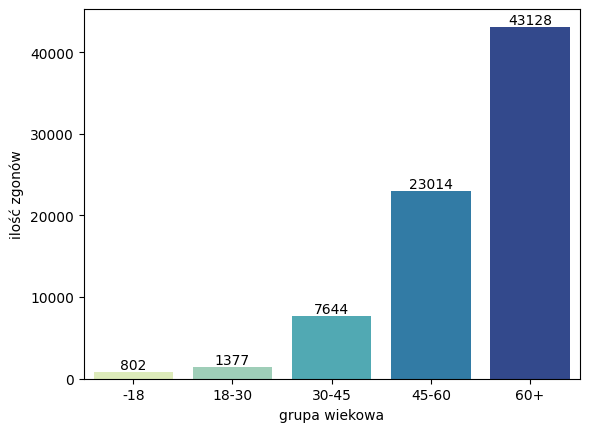

In [35]:
#defeated by date of death in each age group
ax = sns.barplot(x="AGE_GROUP", y="DEAD", estimator="sum", data=covid_age, palette="YlGnBu")
for container in ax.containers:
    ax.bar_label(container)
ax.set(xlabel="grupa wiekowa", ylabel="ilość zgonów")

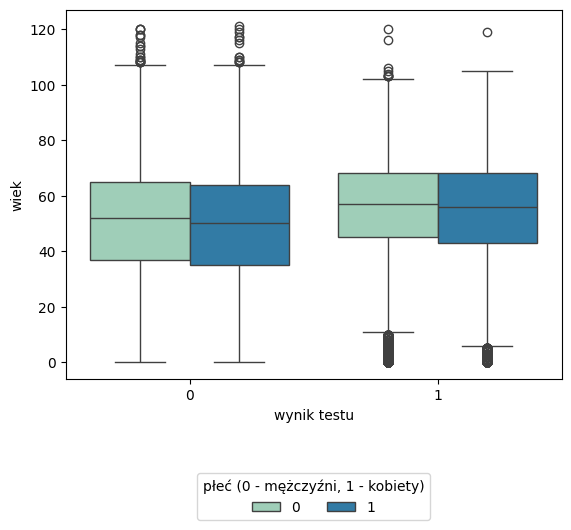

In [36]:
#median and quartiles
ax = sns.boxplot(x="COVID_TEST_RESULT", y="AGE", data=covid, hue="SEX", palette="YlGnBu")
ax.set(xlabel="wynik testu", ylabel="wiek")
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, -0.4), ncol=2, title="płeć (0 - mężczyźni, 1 - kobiety)", frameon=True)

In [37]:
#create a table with column's values 0,1
covid_sick = covid[['COVID_TEST_RESULT','HOSPITALIZED','INTUBED','ADMITTED_TO_ICU','DEAD','AGE','SEX','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED','CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']]

In [38]:
#only positive covid patients
covid_sick = covid_sick.loc[(covid_sick['COVID_TEST_RESULT'] == 1)]

In [39]:
#create a list of conditions to be correlated with death
conditions = ['INTUBED','ADMITTED_TO_ICU', 'AGE','SEX','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED','CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']

korelacja pearsona - zły przykład, bo to dla wartości ciagłych a mamy 0,1

In [40]:
#correlating in for loop and creating a dictionary
death_corrs = {}
for condition in conditions:
    corr = round(covid_sick[condition].corr(covid_sick["DEAD"]),3)
    death_corrs[condition] = corr

In [41]:
#list with sorted correlations
death_corrs = sorted(death_corrs.items(), key=lambda x: x[1], reverse=True)

In [42]:
death_corrs

[('PNEUMONIA', 0.392),
 ('INTUBED', 0.39),
 ('AGE', 0.33),
 ('ADMITTED_TO_ICU', 0.09),
 ('DIABETES', 0.072),
 ('HIPERTENSION', 0.066),
 ('CHRONIC_KIDNEY_DISEASE', 0.006),
 ('COPD', -0.017),
 ('CARDIOVASCULAR_DISEASE', -0.051),
 ('IMMUNOSUPPRESSED', -0.059),
 ('OTHER_DISEASE', -0.059),
 ('OBESITY', -0.078),
 ('PREGNANT', -0.081),
 ('SMOKER', -0.113),
 ('SEX', -0.129),
 ('ASTHMA', -0.139)]

CREATE A LOGISTIC REGRESION MODEL - to będzie dobry przykład, który omawialiśmy z Mateuszem na zajeciach

In [43]:
#split dataset in features (X) and target variable (Y)
#create a list of conditions to be correlated with death
features = ['INTUBED','ADMITTED_TO_ICU', 'AGE','SEX','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED','CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']
X = covid_sick[features] # Features
y = covid_sick["DEAD"] # Target variable

In [44]:
# import the logistic regresion class
from sklearn.linear_model import LogisticRegression

# create the model
model_logreg = LogisticRegression()

# fit the model with data
model_logreg.fit(X, y)

#create prediction
y_pred = model_logreg.predict(X)


c:\Users\bartb\anaconda3\envs\infoshare_virtual_env\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


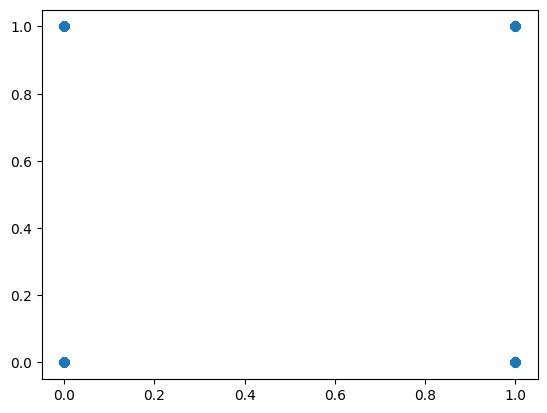

In [45]:
#plot pneumonia vs dead logistic regresion, but without differenciate the size of dots
plt.scatter(covid_sick["PNEUMONIA"], covid_sick["DEAD"])
plt.show
pass

In [46]:
# import the metrics class
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(y, y_pred)
confusion_matrix

array([[46966, 12974],
       [14791, 38557]], dtype=int64)

Text(0.5, 23.52222222222222, 'PREDICTED_DEAD')

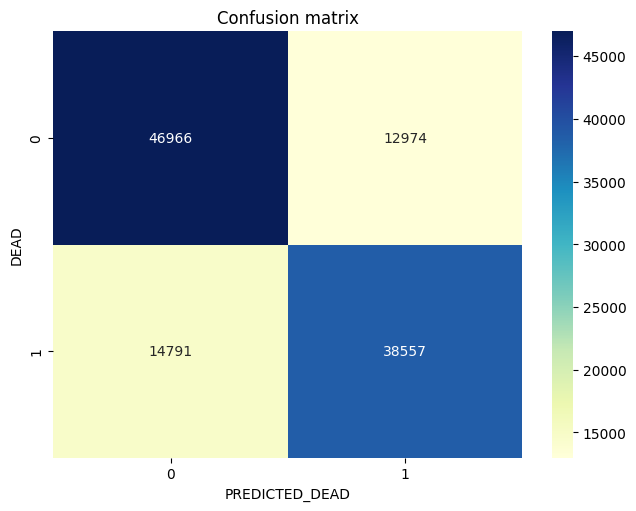

In [47]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(confusion_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("bottom")
plt.tight_layout()
plt.title('Confusion matrix')
plt.ylabel('DEAD')
plt.xlabel('PREDICTED_DEAD')


In [48]:
from sklearn.metrics import classification_report

target_names = ['no covid', 'covid']
print(classification_report(y, y_pred, target_names=target_names))

              precision    recall  f1-score   support

    no covid       0.76      0.78      0.77     59940
       covid       0.75      0.72      0.74     53348

    accuracy                           0.75    113288
   macro avg       0.75      0.75      0.75    113288
weighted avg       0.75      0.75      0.75    113288



powyżej - skuteczność (precyzja) modelu to ok 75% - pytanie czy to wystarczająca wartość, czy da się podciągnąć wydajność modelu

In [49]:
#   CREATE A COEFICIENCY ARRAY FOR FEATURES AND DEAD IN LOGISTIC REGRESION
coeficiencies = logreg.coef_

NameError: name 'logreg' is not defined

In [ ]:
#create keys and values for a dictionary
values = []
for i in coeficiencies[0]:
    exp_coef = np.exp(i)
    values.append(exp_coef)

keys = features

print(keys)
print(values)

['INTUBED', 'ADMITTED_TO_ICU', 'AGE', 'SEX', 'PREGNANT', 'SMOKER', 'PNEUMONIA', 'COPD', 'ASTHMA', 'IMMUNOSUPPRESSED', 'CARDIOVASCULAR_DISEASE', 'HIPERTENSION', 'CHRONIC_KIDNEY_DISEASE', 'DIABETES', 'OBESITY', 'OTHER_DISEASE']
[9.132682815050599, 0.4514421061312601, 1.041207804724888, 0.6138041455276965, 0.3614800498325118, 0.47940583976330575, 3.961402433312058, 0.6839909873701778, 0.40634376338345163, 0.6617843956287944, 0.5726567052092048, 0.960861007139191, 1.153007462025574, 1.0903798402629925, 0.8487780682804891, 0.7626058964890655]


In [ ]:
#create a dictionary with results
death_logreg = dict(zip(keys, values))
print(death_logreg)


{'INTUBED': 9.132682815050599, 'ADMITTED_TO_ICU': 0.4514421061312601, 'AGE': 1.041207804724888, 'SEX': 0.6138041455276965, 'PREGNANT': 0.3614800498325118, 'SMOKER': 0.47940583976330575, 'PNEUMONIA': 3.961402433312058, 'COPD': 0.6839909873701778, 'ASTHMA': 0.40634376338345163, 'IMMUNOSUPPRESSED': 0.6617843956287944, 'CARDIOVASCULAR_DISEASE': 0.5726567052092048, 'HIPERTENSION': 0.960861007139191, 'CHRONIC_KIDNEY_DISEASE': 1.153007462025574, 'DIABETES': 1.0903798402629925, 'OBESITY': 0.8487780682804891, 'OTHER_DISEASE': 0.7626058964890655}


na razie to słownik, pozostaje interpretacja z uwzględnieniem, czy korelacja była ujemna czy dodatnia

In [ ]:
np.exp(2.2118595)

9.132682837335953

WNIOSEK - jesli pajent byl intubowany to ryzyko zgonu wzrasta x9

In [ ]:
np.exp(0.04038139)

1.0412078047204814

WNIOSEK - z każdym rokiem życia pacjenta ryzyko zgonu wzrasta o 4% (YoY)

In [ ]:
class Patient